In [1]:
import pandas as pd

# 1. Load the CSV file
# Replace 'your_file.csv' with the actual path to your file
file_path = 'youtube-comments-sentiment-400k.csv'
df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')

# 2. Check the number of rows
# df.shape returns (rows, columns)
num_rows = df.shape[0]
print(f"Total Number of Rows: {num_rows}")

# 3. Check the headers
print("\nHeaders:")
print(df.columns.tolist())

# 4. Show the first 20 rows
print("\nFirst 20 Rows:")
print(df.head(20))

Total Number of Rows: 307058

Headers:
['CommentID', 'VideoID', 'VideoTitle', 'AuthorName', 'AuthorChannelID', 'CommentText', 'Sentiment', 'Likes', 'Replies', 'PublishedAt', 'CountryCode', 'CategoryID']

First 20 Rows:
                         CommentID      VideoID  \
0       UgyRjrEdJIPrf68uND14AaABAg  mcY4M9gjtsI   
1       UgxXxEIySAwnMNw8D7N4AaABAg  2vuXcw9SZbA   
2       UgxB0jh2Ur41mcXr5IB4AaABAg  papg2tsoFzg   
3       UgwMOh95MfK0GuXLLrF4AaABAg  31KTdfRH6nY   
4       UgxJuUe5ysG8OSbABAl4AaABAg  -hV6aeyPHPA   
5       UgzoTpY5F11FtcooFRR4AaABAg  NnJ4XJdZW4I   
6       UgzJ-2rV0-YNPyMj0u14AaABAg  X4wNLFrv9Co   
7       UgwuFh4s9cHu3dHrPqJ4AaABAg  sKniMxl9zwo   
8       UgwzYX76p4RK8AHVcYN4AaABAg  yUImrnDqGUk   
9       UgzW7h-gmtmgIFFClLJ4AaABAg  5VPxcrvVkBc   
10      UgyqrXh3SW_NpUqyc_Z4AaABAg  eWRfhZUzrAc   
11      UgzJHIMWZvO9VfFKMSx4AaABAg  0Da7hDTXXlw   
12      UgwSey7F61ABVTUJs-N4AaABAg  WTLPmUHTPqo   
13      UgyPCDWsN3YHnh-x85h4AaABAg  PyfKCvHALj8   
14      UgxYiI99

In [4]:
columns_to_keep = ['CommentText', 'Sentiment', 'Likes', 'Replies','CountryCode', 'CategoryID']
df_filtered = df[columns_to_keep].copy()

In [5]:
# Filter rows where CommentText length is between 5 and 1000 characters
df_filtered = df_filtered[df_filtered['CommentText'].str.len().between(5, 1000)]

# Display the shape of the filtered DataFrame and the first 5 rows
print(f"Shape of the filtered DataFrame: {df_filtered.shape}")
display(df_filtered.head())

Shape of the filtered DataFrame: (299908, 6)


,CommentText,Sentiment,Likes,Replies,CountryCode,CategoryID
0,Anyone know what movie this is?,Neutral,0,2,NZ,1
1,The fact they're holding each other back while...,Positive,0,0,AU,17
2,waiting next video will be?,Neutral,1,0,IN,27
3,Thanks for the great video.\r\n\r\nI don't und...,Neutral,0,1,US,27
4,Good person helping good people.\r\nThis is ho...,Positive,3,1,US,2


In [7]:
# Filter out comments containing newline characters (multiline comments)
df_single_line_comments = df_filtered[~df_filtered['CommentText'].str.contains(r'\n|\r', regex=True)]

# Display the shape of the new DataFrame and the first 5 rows
print(f"Shape of DataFrame after filtering multiline comments: {df_single_line_comments.shape}")
display(df_single_line_comments.head())

Shape of DataFrame after filtering multiline comments: (275144, 6)


,CommentText,Sentiment,Likes,Replies,CountryCode,CategoryID
0,Anyone know what movie this is?,Neutral,0,2,NZ,1
1,The fact they're holding each other back while...,Positive,0,0,AU,17
2,waiting next video will be?,Neutral,1,0,IN,27
5,Dei løk de seim😂,Neutral,0,0,NZ,1
6,Number two because it looks the best with it,Positive,0,0,US,28


In [8]:
# Save the filtered DataFrame to a new CSV file
df_single_line_comments.to_csv('filtered_youtube_comments2.csv', index=False)
print("Filtered data saved to 'filtered_youtube_comments.csv'")

Filtered data saved to 'filtered_youtube_comments.csv'


/tmp/ipykernel_1062/273998401.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_single_line_comments, x='Sentiment', palette='viridis')


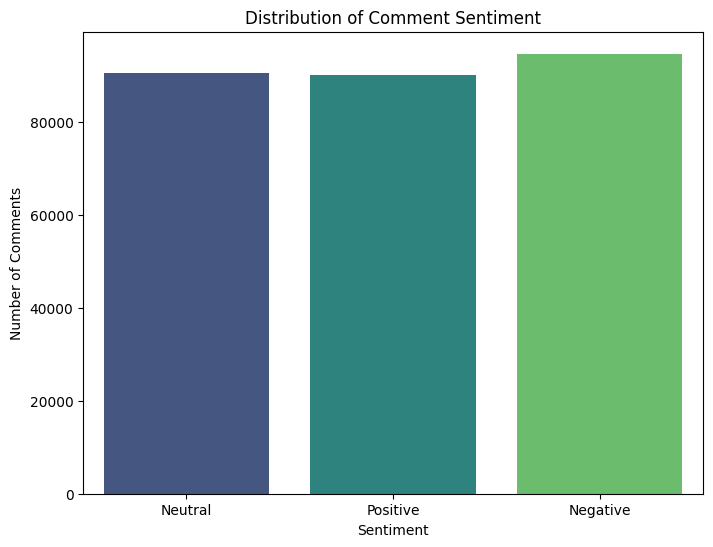

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of 'Sentiment'
plt.figure(figsize=(8, 6))
sns.countplot(data=df_single_line_comments, x='Sentiment', hue='Sentiment', palette='viridis', legend=False)
plt.title('Distribution of Comment Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()